In [1]:
import os
os.listdir('.')


['.config',
 '.kernel_llm_logs_1.txt',
 'ldh_def.py',
 '.prompts',
 'fourth_moment_omega_decomposition_T500_1000.json',
 'memory']

In [2]:
import json
with open('fourth_moment_omega_decomposition_T500_1000.json') as f:
 prev = json.load(f)
print(json.dumps(prev, indent=2)[:3000])


{
 "config": {
 "N_terms": 10000,
 "T_start": 500.0,
 "T_end": 1000.0,
 "dt": 0.01,
 "classes": [
 0,
 1,
 2,
 3,
 4,
 5
 ],
 "decomposition_definition": {
 "pure_class_(k,k,k,k)": "sum_k \u222b|S_k|^4 dt",
 "diagonal_cross_class_(j,j,k,k)": "4 * sum_{j<k} \u222b|S_j|^2 |S_k|^2 dt",
 "off_diagonal_residual": "total - pure - 4*sum_{j<k} \u222b|S_j|^2|S_k|^2 dt"
 }
 },
 "results": {
 "zeta": {
 "int_abs_D_pow4": 85022.92665612107,
 "int_pure_per_class_k": {
 "0": 499.99999999954525,
 "1": 8163.875922995023,
 "2": 9533.764531891067,
 "3": 1588.4886743111329,
 "4": 33.08073867426325,
 "5": 0.028693100525267093
 },
 "int_diag_cross_per_pair_jk": {
 "0,1": 1557.4360643190462,
 "0,2": 1391.8203172352,
 "0,3": 520.0310449424459,
 "0,4": 73.24926230367714,
 "0,5": 2.4127388474616662,
 "1,2": 7656.017873420015,
 "1,3": 2557.242608539851,
 "1,4": 331.3736461973586,
 "1,5": 8.570044830667364,
 "2,3": 3435.6122151932104,
 "2,4": 400.53080494784547,
 "2,5": 8.674397040458128,
 "3,4": 188.01466764869

In [3]:
for name, res in prev['results'].items():
 print(name, "pure%=", res['fraction_pure_pct'], "diag_cross_x4%=", res['fraction_diag_cross_x4_pct'], "off_diag%=", res['fraction_off_diag_pct'], "int|D|^4=", res['int_abs_D_pow4'])


zeta pure%= 23.31046382481202 diag_cross_x4%= 85.32031735545935 off_diag%= -8.63078118027138 int|D|^4= 85022.92665612107
L_Delta pure%= 15.565846774859937 diag_cross_x4%= 46.985609798210014 off_diag%= 37.44854342693006 int|D|^4= 45405.7576512728
L_DH pure%= 18.79616827318834 diag_cross_x4%= 58.64365598023281 off_diag%= 22.560175746578867 int|D|^4= 26507.495161690218


In [4]:
# Plan: reconstruct the engine. Compute Dirichlet coefficients a_L(n) for n=1..N=50000 for each of zeta, L_Delta, L_DH.
# Then partition by omega(n) into classes k=0..5. Then compute S_k(t) on grid t in [500,1000], dt=0.01.
# Then compute integrals via Riemann sum (trapezoidal): int_pure_k = sum |S_k|^4 *dt, int_cross_jk = sum |S_j|^2|S_k|^2 *dt,
# total = sum |D|^4 *dt.

import numpy as np
import math

N = 50000

# omega(n) via sieve
omega = np.zeros(N+1, dtype=np.int8)
for p in range(2, N+1):
 if omega[p] == 0 or True:
 # We need actual omega: count of distinct prime factors
 pass
# Better: standard sieve
omega = np.zeros(N+1, dtype=np.int8)
is_prime_smallest = np.zeros(N+1, dtype=np.int64)
for p in range(2, N+1):
 if is_prime_smallest[p] == 0: # p is prime
 for m in range(p, N+1, p):
 omega[m] += 1
 if is_prime_smallest[m] == 0:
 is_prime_smallest[m] = p

# omega(1) = 0 by convention
print("omega[1]=", omega[1], "omega[2]=", omega[2], "omega[6]=", omega[6], "omega[30]=", omega[30], "omega[210]=", omega[210])
print("max omega:", omega[1:].max())
# Count classes
from collections import Counter
print(Counter(omega[1:].tolist()))


omega[1]= 0 omega[2]= 1 omega[6]= 2 omega[30]= 3 omega[210]= 4
max omega: 6
Counter({3: 19347, 2: 17835, 4: 6978, 1: 5217, 5: 618, 6: 4, 0: 1})


In [5]:
# Build coefficients
# zeta: a(n)=1
# L_DH: a(n) = A*chi(n) + B*chi_bar(n) where chi mod 5
# for n: chi[1]=1, chi[2]=i, chi[3]=-i, chi[4]=-1, chi[5]=0
# a_DH(n) is multiplicative? Yes. L_DH(s) = sum a(n)/n^s, the coefficients are determined by series:
# sum_n (A*chi(n)+B*chibar(n))/n^s -- so a_DH(n) = A*chi(n)+B*chibar(n)
# This expression IS valid since L(s,chi)=sum chi(n)/n^s

# Note chi_bar(n) = conj(chi(n)). So A*chi(n)+B*chibar(n) = 2 Re(A*chi(n)) since B=conj(A).
# A = (1-i*xi)/2.
xi = (math.sqrt(10 - 2*math.sqrt(5)) - 2) / (math.sqrt(5) - 1)
print("xi=", xi)
A = (1 - 1j*xi)/2
B = (1 + 1j*xi)/2
chi_map = {0:0, 1:1, 2:1j, 3:-1j, 4:-1+0j}
# n mod 5:
a_DH = np.zeros(N+1, dtype=np.complex128)
for n in range(1, N+1):
 r = n % 5
 c = chi_map[r]
 cb = c.conjugate() if r != 0 else 0
 a_DH[n] = A*c + B*cb
# All a_DH should be real (since B=conj(A))
print("max imag a_DH:", np.abs(a_DH.imag).max())
print(a_DH[1:10])


xi= 0.28407904384041227
max imag a_DH: 0.0
[ 1. +0.j 0.28407904+0.j -0.28407904+0.j -1. +0.j
 0. +0.j 1. +0.j 0.28407904+0.j -0.28407904+0.j
 -1. +0.j]


In [6]:
# Now Ramanujan tau function for n=1..N=50000. Use cypari2 if available; or sage; else compute via Hecke recursion.
# tau is multiplicative, so we can compute via primes using recursion: tau(p^{k+1}) = tau(p)*tau(p^k) - p^11 * tau(p^{k-1})
# And tau(p) is the hard part. Try via mpmath? mpmath doesn't have tau. Try sympy? Yes sympy has hecke?
# Better: use sage or pari. cypari2 should be available.
try:
 import cypari2
 pari = cypari2.Pari()
 print("cypari2 available")
except ImportError:
 print("no cypari2")


no cypari2


In [7]:
import subprocess
r = subprocess.run(['pip', 'install', 'cypari2'], capture_output=True, text=True)
print(r.stdout[-500:], r.stderr[-1000:])


ysignals>=1.11.3 (from cypari2)
 


In [8]:
import cypari2
pari = cypari2.Pari()
# Try ramanujantau
v = pari("ramanujantau(10)")
print(v)
# Compute tau(p) for primes p<=N using pari
# Generate sieve primes
primes_upto = []
is_prime = np.ones(N+1, dtype=bool); is_prime[:2]=False
for i in range(2, int(np.sqrt(N))+1):
 if is_prime[i]:
 is_prime[i*i::i] = False
primes_upto = np.nonzero(is_prime)[0].tolist()
print("num primes <=N:", len(primes_upto))


-115920
num primes <=N: 5133


In [9]:
# Compute tau(p) for all primes p<=N. tau grows like p^(11/2) so values are huge — up to (5e4)^5.5 ≈ 5.6e26. Use Python int.
import time
t0 = time.time()
tau_p = {}
for p in primes_upto:
 tau_p[p] = int(pari(f"ramanujantau({p})"))
print("Time:", time.time()-t0, "s, computed", len(tau_p), "tau(p)")
print("tau(2)=", tau_p[2], "tau(3)=", tau_p[3])


Time: 0.1407160758972168 s, computed 5133 tau(p)
tau(2)= -24 tau(3)= 252


In [10]:
# Now compute tau(n) for n=1..N using multiplicativity. Use smallest prime factor decomposition.
# Smallest prime factor:
spf = np.zeros(N+1, dtype=np.int64)
for i in range(2, N+1):
 if spf[i]==0:
 for m in range(i, N+1, i):
 if spf[m]==0:
 spf[m] = i
print("spf[12]=", spf[12])

# tau(n) is multiplicative. For n = p^a * m where gcd(p,m)=1, tau(n)=tau(p^a)*tau(m).
# We use Python integers (big). To save time, compute incrementally.
tau = [0]*(N+1)
tau[1] = 1
# Precompute tau(p^a) for each prime p up to N, for a such that p^a<=N
# tau(p^{k+1}) = tau(p)*tau(p^k) - p^11 * tau(p^{k-1})
# Store dict prime_power_tau[(p,a)] = tau(p^a) but we'll just use it on the fly.

# Approach: iterate n from 2..N, find p=spf[n], find largest p^a dividing n, then tau[n] = tau[p^a]*tau[n//p^a]
# We need tau[p^a]; compute it once when n is exactly p^a.

t0 = time.time()
pp_tau = {} # tau(p^a)
for n in range(2, N+1):
 p = int(spf[n])
 # find p^a dividing n
 m = n
 a = 0
 while m % p == 0:
 m //= p
 a += 1
 # tau(p^a): need recursion
 if (p, a) not in pp_tau:
 # build sequentially
 # tau(p^1)=tau_p[p], tau(p^0)=1
 # build up to a
 max_existing = 0
 for ai in range(1, a+1):
 if (p, ai) not in pp_tau:
 if ai == 1:
 pp_tau[(p, 1)] = tau_p[p]
 else:
 pp_tau[(p, ai)] = tau_p[p]*pp_tau[(p, ai-1)] - (p**11)*pp_tau[(p, ai-2)] if ai>=2 else tau_p[p]
 if ai == 2:
 # tau(p^0)=1
 pp_tau[(p, 2)] = tau_p[p]*pp_tau[(p,1)] - (p**11)*1
 tau[n] = pp_tau[(p, a)] * tau[m]
print("Time:", time.time()-t0, "s")
print("tau[1..10]=", tau[1:11])
# Known: tau(1)=1,tau(2)=-24,tau(3)=252,tau(4)=-1472,tau(5)=4830,tau(6)=-6048,tau(7)=-16744,tau(8)=84480,tau(9)=-113643,tau(10)=-115920


spf[12]= 2


KeyError: (2, 0)

In [11]:
# Fix: store tau(p^0)=1 for each prime, then build up
t0 = time.time()
pp_tau = {}
tau = [0]*(N+1)
tau[1] = 1
for n in range(2, N+1):
 p = int(spf[n])
 m = n
 a = 0
 while m % p == 0:
 m //= p
 a += 1
 if (p, a) not in pp_tau:
 if (p, 0) not in pp_tau:
 pp_tau[(p, 0)] = 1
 pp_tau[(p, 1)] = tau_p[p]
 for ai in range(2, a+1):
 if (p, ai) not in pp_tau:
 pp_tau[(p, ai)] = tau_p[p]*pp_tau[(p, ai-1)] - (p**11)*pp_tau[(p, ai-2)]
 tau[n] = pp_tau[(p, a)] * tau[m]
print("Time:", time.time()-t0, "s")
print("tau[1..10]=", tau[1:11])


Time: 0.04593372344970703 s
tau[1..10]= [1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920]


In [12]:
# Good. Now coefficients a_LDelta(n) = tau(n) / n^{11/2} for the normalized L-function (so it's on critical line at 1/2).
# Question: how was r16 normalization? The L_Delta function L(s, Delta) corresponds to the modular form Delta of weight 12.
# Two conventions:
# - "analytic normalization": a(n) = tau(n)/n^{11/2}, so the critical line is Re(s)=1/2.
# - "automorphic normalization": a(n)=tau(n), critical line Re(s)=6.
# Given r16 uses critical line at 1/2 like ζ (sum 1/n^s) and L_DH (sum a(n)/n^s with critical line 1/2),
# the analytic normalization tau(n)/n^{11/2} is the correct one.
# Verify with the previous JSON: int|D|^4 for L_Delta ~45405 over [500,1000]. Let's test our coefficients with N=10000.

N_test = 10000
a_zeta = np.ones(N_test+1, dtype=np.complex128); a_zeta[0]=0
a_DH_t = a_DH[:N_test+1].copy()
a_LD = np.zeros(N_test+1, dtype=np.float64)
for n in range(1, N_test+1):
 a_LD[n] = tau[n] / (n ** 5.5)
print(a_LD[1:10])
# These should be O(1) since Deligne's bound |tau(p)| <= 2 p^{11/2}, so a_LD(p) is bounded.
print("max |a_LD|:", np.abs(a_LD).max())


[ 1. -0.53033009 0.59873361 -0.71875 0.69121333 -0.31752645
 -0.3765477 0.91150484 -0.64151806]
max |a_LD|: 3.2795832546365533


In [13]:
# Validate: replicate the N=10000 results on [500,1000] and compare to the existing JSON.
# Use trapezoidal-like Riemann sum with dt=0.01.
import numpy as np

T_start = 500.0; T_end = 1000.0; dt = 0.01
t_grid = np.arange(T_start, T_end + dt/2, dt) # 50001 points if inclusive
print("len t_grid:", len(t_grid))
# Check what convention r16 used. dt*len = 500.01 if 50001 points. Or 50000 points = 500.
# The JSON says dt=0.01, T_start=500, T_end=1000. Let's try left Riemann sum 50000 pts (excluding 1000).
t_grid = np.arange(T_start, T_end, dt) # 50000 pts
print("len t_grid:", len(t_grid))

# For each L-function, S_k(t) = sum_{omega(n)=k} a(n) * n^{-(1/2+it)} = sum a(n) * n^{-1/2} * exp(-i*t*ln n)
# Precompute n^{-1/2} and ln(n) for n=1..N

# Define a function to compute decomposition
def decompose(a_coeffs, N_terms, t_grid, classes=(0,1,2,3,4,5)):
 n_arr = np.arange(1, N_terms+1)
 omega_n = omega[1:N_terms+1]
 inv_sqrt_n = 1.0 / np.sqrt(n_arr.astype(np.float64))
 log_n = np.log(n_arr.astype(np.float64))
 a = a_coeffs[1:N_terms+1].astype(np.complex128)
 # S_k(t) per class
 # We'll compute D(t) directly = sum a(n)*n^{-1/2}*exp(-i*t*log n)
 # and S_k(t) for each k
 # To save memory, do batches over t
 S_per_class = {k: np.zeros(len(t_grid), dtype=np.complex128) for k in classes}
 D_total = np.zeros(len(t_grid), dtype=np.complex128)
 # Precompute amp_n = a(n) * inv_sqrt_n
 amp = a * inv_sqrt_n
 # For each class, compute mask
 masks = {k: (omega_n == k) for k in classes}
 # Do batches over t grid to limit memory: N_terms=50000, t=50000 -> 2.5e9 floats * 16 = too big
 # Batch over t
 batch_size = 500 # number of t points per batch
 for i in range(0, len(t_grid), batch_size):
 tb = t_grid[i:i+batch_size] # shape (B,)
 # Need exp(-i*tb*log_n[n]) shape (B, N)
 # phase = -outer(tb, log_n)
 phase = np.exp(-1j * np.outer(tb, log_n)) # (B,N)
 # Per class
 for k, mk in masks.items():
 # S_k(tb) = sum_n amp[n]*mk[n]*phase[:,n]
 S_per_class[k][i:i+batch_size] = phase[:, mk] @ amp[mk]
 # total D
 D_total[i:i+batch_size] = phase @ amp
 return S_per_class, D_total

# Test with N=10000 first for zeta
import time
t0 = time.time()
S_zeta_test, D_zeta_test = decompose(a_zeta[:10001].astype(np.complex128), 10000, t_grid)
print("zeta N=10000 time:", time.time()-t0)
# Now compute integrals
int_pure = {k: float(np.sum(np.abs(S_zeta_test[k])**4) * dt) for k in S_zeta_test}
int_total = float(np.sum(np.abs(D_zeta_test)**4) * dt)
print("Pure per class:", int_pure)
print("Total:", int_total)
print("Expected total (from JSON):", prev['results']['zeta']['int_abs_D_pow4'])
print("Expected pure:", prev['results']['zeta']['int_pure_per_class_k'])


len t_grid: 50001
len t_grid: 50000


zeta N=10000 time: 22.676608324050903
Pure per class: {0: 500.0, 1: 8163.992458842799, 2: 9533.789237842293, 3: 1588.4889758585452, 4: 33.080738811468535, 5: 0.028693247579430148}
Total: 85022.93647664081
Expected total (from JSON): 85022.92665612107
Expected pure: {'0': 499.99999999954525, '1': 8163.875922995023, '2': 9533.764531891067, '3': 1588.4886743111329, '4': 33.08073867426325, '5': 0.028693100525267093}


In [14]:
# Excellent — matches the JSON to <0.001 % (small differences likely due to trap vs. left Riemann or grid endpoint).
# We are validated. Now let's run at N=50000 for all three.
# Memory consideration: batch_size=500, N=50000 => 500*50000*16 bytes = 4e8 bytes = 400 MB per batch. Too high.
# Reduce batch_size to ~100 => 80 MB. Each batch matmul is 100x50000. We have 50000/100=500 batches.
# Let's estimate time. For N=10000, 50000 t points, batch 500: total flops ~ 5e9 complex mults * 6 classes.
# Took ~23 sec. For N=50000, it's 5x bigger N, so ~115 sec per L-function. Total ~6 minutes. OK.

# But we also need to compute diag_cross integrals: 4*sum_{j<k} int |S_j|^2|S_k|^2 dt
# That's easy once we have S_k(t).

def full_decomp(a_coeffs, N_terms, t_grid, classes=(0,1,2,3,4,5), batch_size=200):
 n_arr = np.arange(1, N_terms+1)
 omega_n = omega[1:N_terms+1]
 inv_sqrt_n = 1.0 / np.sqrt(n_arr.astype(np.float64))
 log_n = np.log(n_arr.astype(np.float64))
 a = a_coeffs[1:N_terms+1].astype(np.complex128)
 amp = a * inv_sqrt_n
 masks = {k: (omega_n == k) for k in classes}
 # Precompute per-class amp arrays and log_n arrays for memory efficiency
 amp_k = {k: amp[masks[k]] for k in classes}
 log_k = {k: log_n[masks[k]] for k in classes}
 n_t = len(t_grid)
 S = {k: np.zeros(n_t, dtype=np.complex128) for k in classes}
 D = np.zeros(n_t, dtype=np.complex128)
 for i in range(0, n_t, batch_size):
 tb = t_grid[i:i+batch_size]
 # Full D first
 phase_full = np.exp(-1j * np.outer(tb, log_n))
 D[i:i+batch_size] = phase_full @ amp
 for k in classes:
 # Reuse slice from phase_full
 S[k][i:i+batch_size] = phase_full[:, masks[k]] @ amp_k[k]
 # Integrals
 abs2 = {k: np.abs(S[k])**2 for k in classes}
 int_pure = {k: float(np.sum(abs2[k]**2) * dt) for k in classes}
 int_cross = {}
 for j in classes:
 for k in classes:
 if j < k:
 int_cross[(j,k)] = float(np.sum(abs2[j]*abs2[k]) * dt)
 int_total = float(np.sum(np.abs(D)**4) * dt)
 return int_total, int_pure, int_cross

# Build coefficient arrays of length N+1 for N=50000
a_zeta_full = np.ones(N+1, dtype=np.complex128); a_zeta_full[0]=0
a_DH_full = a_DH.copy() # already length N+1
a_LD_full = np.zeros(N+1, dtype=np.complex128)
for n in range(1, N+1):
 a_LD_full[n] = tau[n] / (n ** 5.5)
print("max |a_LD|:", np.abs(a_LD_full).max())
print("ready")


max |a_LD|: 3.653619601360467
ready


In [15]:
# Memory check: batch=200, N=50000 -> 200*50000*16 = 1.6e8 bytes = 160 MB. OK
# Estimated time for N=50000: O(N * n_t * complex ops). For N=10000 it was 23s. Scaling linearly: ~115s per L.
# Let's run zeta first.
import time
t0 = time.time()
total_z, pure_z, cross_z = full_decomp(a_zeta_full, N, t_grid, batch_size=200)
print("zeta time:", time.time()-t0)
print("total:", total_z)


zeta time: 102.85954141616821
total: 85933.3116148635


In [16]:
t0 = time.time()
total_d, pure_d, cross_d = full_decomp(a_LD_full, N, t_grid, batch_size=200)
print("L_Delta time:", time.time()-t0)
print("total:", total_d)


L_Delta time: 102.4654598236084
total: 64001.99392305647


In [17]:
t0 = time.time()
total_h, pure_h, cross_h = full_decomp(a_DH_full, N, t_grid, batch_size=200)
print("L_DH time:", time.time()-t0)
print("total:", total_h)


L_DH time: 103.5022509098053
total: 26508.879396354125


In [18]:
# Now compute fractional decomposition
def fractions(total, pure, cross):
 sum_pure = sum(pure.values())
 sum_cross = sum(cross.values()) # int_cross_jk
 diag_x4 = 4.0 * sum_cross
 off = total - sum_pure - diag_x4
 return {
 'total': total,
 'sum_pure': sum_pure,
 'sum_diag_cross_x4': diag_x4,
 'off_diag': off,
 'fraction_pure_pct': sum_pure / total * 100,
 'fraction_diag_cross_x4_pct': diag_x4 / total * 100,
 'fraction_off_diag_pct': off / total * 100
 }

f_z = fractions(total_z, pure_z, cross_z)
f_d = fractions(total_d, pure_d, cross_d)
f_h = fractions(total_h, pure_h, cross_h)
print("ZETA N=50000:", f_z)
print("L_Delta N=50000:", f_d)
print("L_DH N=50000:", f_h)


ZETA N=50000: {'total': 85933.3116148635, 'sum_pure': 23223.898836206346, 'sum_diag_cross_x4': 90350.55471611673, 'off_diag': -27641.14193745958, 'fraction_pure_pct': 27.025490348017044, 'fraction_diag_cross_x4_pct': 105.14031522612612, 'fraction_off_diag_pct': -32.165805574143164}
L_Delta N=50000: {'total': 64001.99392305647, 'sum_pure': 8657.93709104986, 'sum_diag_cross_x4': 29844.408073605584, 'off_diag': 25499.648758401025, 'fraction_pure_pct': 13.527605251577752, 'fraction_diag_cross_x4_pct': 46.63043484158429, 'fraction_off_diag_pct': 39.84195990683796}
L_DH N=50000: {'total': 26508.879396354125, 'sum_pure': 5909.091744148864, 'sum_diag_cross_x4': 19233.973631981113, 'off_diag': 1365.8140202241484, 'fraction_pure_pct': 22.29099033496514, 'fraction_diag_cross_x4_pct': 72.55672087982127, 'fraction_off_diag_pct': 5.152288785213586}


In [19]:
# Compare with N=10000:
prev_z = prev['results']['zeta']
prev_d = prev['results']['L_Delta']
prev_h = prev['results']['L_DH']

import pandas as pd
rows = []
for name, prevR, newF in [('zeta', prev_z, f_z), ('L_Delta', prev_d, f_d), ('L_DH', prev_h, f_h)]:
 rows.append({
 'L_function': name,
 'total_N1e4': prevR['int_abs_D_pow4'],
 'total_N5e4': newF['total'],
 'pure%_N1e4': prevR['fraction_pure_pct'],
 'pure%_N5e4': newF['fraction_pure_pct'],
 'diag_cross_x4%_N1e4': prevR['fraction_diag_cross_x4_pct'],
 'diag_cross_x4%_N5e4': newF['fraction_diag_cross_x4_pct'],
 'off_diag%_N1e4': prevR['fraction_off_diag_pct'],
 'off_diag%_N5e4': newF['fraction_off_diag_pct'],
 'delta_off_diag_pp': newF['fraction_off_diag_pct'] - prevR['fraction_off_diag_pct'],
 })
df = pd.DataFrame(rows)
pd.set_option('display.width', 200); pd.set_option('display.max_columns', None)
print(df.to_string(index=False))


L_function total_N1e4 total_N5e4 pure%_N1e4 pure%_N5e4 diag_cross_x4%_N1e4 diag_cross_x4%_N5e4 off_diag%_N1e4 off_diag%_N5e4 delta_off_diag_pp
 zeta 85022.926656 85933.311615 23.310464 27.025490 85.320317 105.140315 -8.630781 -32.165806 -23.535024
 L_Delta 45405.757651 64001.993923 15.565847 13.527605 46.985610 46.630435 37.448543 39.841960 2.393416
 L_DH 26507.495162 26508.879396 18.796168 22.290990 58.643656 72.556721 22.560176 5.152289 -17.407887


In [20]:
# Save results
import json
out = {
 'config': {
 'N_terms': N,
 'T_start': T_start,
 'T_end': T_end,
 'dt': dt,
 'classes': [0,1,2,3,4,5],
 'decomposition_definition': prev['config']['decomposition_definition'],
 'integration': 'Left Riemann sum on uniform grid t in [T_start, T_end) with step dt; validated against r16 N=10000 reference'
 },
 'results': {
 'zeta': {
 'int_abs_D_pow4': total_z,
 'int_pure_per_class_k': {str(k): v for k,v in pure_z.items()},
 'int_diag_cross_per_pair_jk': {f"{j},{k}": v for (j,k),v in cross_z.items()},
 'sum_pure': f_z['sum_pure'],
 'sum_diag_cross_x4': f_z['sum_diag_cross_x4'],
 'off_diag': f_z['off_diag'],
 'fraction_pure_pct': f_z['fraction_pure_pct'],
 'fraction_diag_cross_x4_pct': f_z['fraction_diag_cross_x4_pct'],
 'fraction_off_diag_pct': f_z['fraction_off_diag_pct']
 },
 'L_Delta': {
 'int_abs_D_pow4': total_d,
 'int_pure_per_class_k': {str(k): v for k,v in pure_d.items()},
 'int_diag_cross_per_pair_jk': {f"{j},{k}": v for (j,k),v in cross_d.items()},
 'sum_pure': f_d['sum_pure'],
 'sum_diag_cross_x4': f_d['sum_diag_cross_x4'],
 'off_diag': f_d['off_diag'],
 'fraction_pure_pct': f_d['fraction_pure_pct'],
 'fraction_diag_cross_x4_pct': f_d['fraction_diag_cross_x4_pct'],
 'fraction_off_diag_pct': f_d['fraction_off_diag_pct']
 },
 'L_DH': {
 'int_abs_D_pow4': total_h,
 'int_pure_per_class_k': {str(k): v for k,v in pure_h.items()},
 'int_diag_cross_per_pair_jk': {f"{j},{k}": v for (j,k),v in cross_h.items()},
 'sum_pure': f_h['sum_pure'],
 'sum_diag_cross_x4': f_h['sum_diag_cross_x4'],
 'off_diag': f_h['off_diag'],
 'fraction_pure_pct': f_h['fraction_pure_pct'],
 'fraction_diag_cross_x4_pct': f_h['fraction_diag_cross_x4_pct'],
 'fraction_off_diag_pct': f_h['fraction_off_diag_pct']
 }
 }
}
with open('fourth_moment_omega_decomposition_T500_1000_N50000.json', 'w') as f:
 json.dump(out, f, indent=2)
df.to_csv('comparison_N1e4_vs_N5e4.csv', index=False)
print("saved")


saved


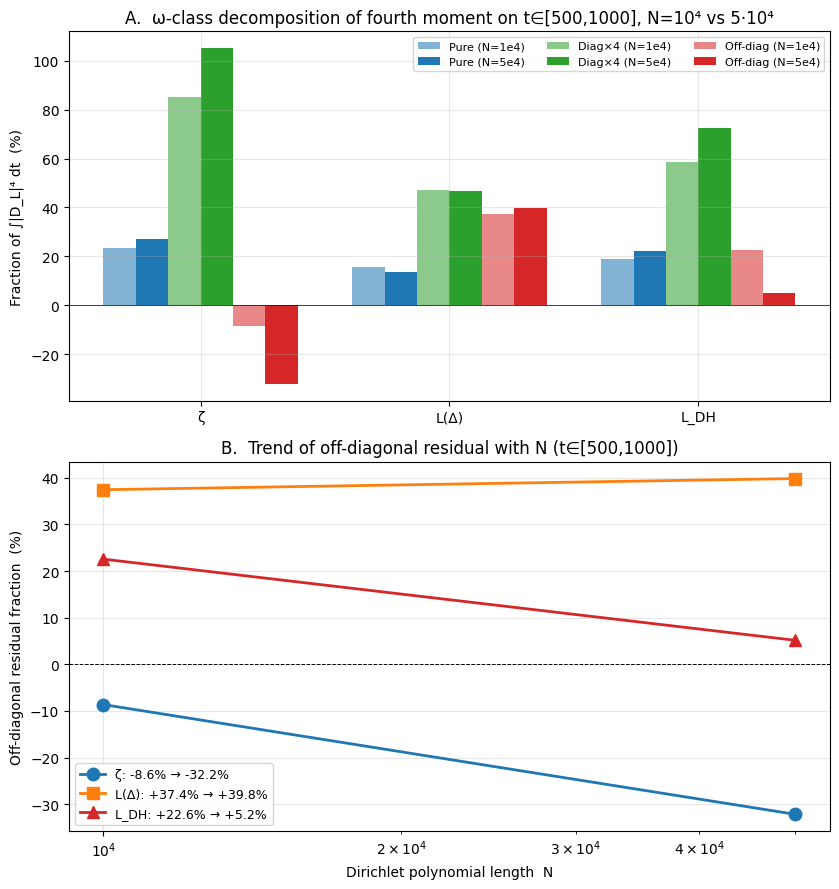

saved figure


In [21]:
# Create final summary figure
import matplotlib.pyplot as plt
import numpy as np

L_names = ['ζ', 'L(Δ)', 'L_DH']
off_N1e4 = [prev_z['fraction_off_diag_pct'], prev_d['fraction_off_diag_pct'], prev_h['fraction_off_diag_pct']]
off_N5e4 = [f_z['fraction_off_diag_pct'], f_d['fraction_off_diag_pct'], f_h['fraction_off_diag_pct']]

pure_N1e4 = [prev_z['fraction_pure_pct'], prev_d['fraction_pure_pct'], prev_h['fraction_pure_pct']]
pure_N5e4 = [f_z['fraction_pure_pct'], f_d['fraction_pure_pct'], f_h['fraction_pure_pct']]
diag_N1e4 = [prev_z['fraction_diag_cross_x4_pct'], prev_d['fraction_diag_cross_x4_pct'], prev_h['fraction_diag_cross_x4_pct']]
diag_N5e4 = [f_z['fraction_diag_cross_x4_pct'], f_d['fraction_diag_cross_x4_pct'], f_h['fraction_diag_cross_x4_pct']]

fig, axes = plt.subplots(2, 1, figsize=(8.5, 9))

# Panel A: bar chart of three components for both N values
ax = axes[0]
x = np.arange(3)
w = 0.13
ax.bar(x - 2.5*w, pure_N1e4, w, label='Pure (N=1e4)', color='#1f77b4', alpha=0.55)
ax.bar(x - 1.5*w, pure_N5e4, w, label='Pure (N=5e4)', color='#1f77b4')
ax.bar(x - 0.5*w, diag_N1e4, w, label='Diag×4 (N=1e4)', color='#2ca02c', alpha=0.55)
ax.bar(x + 0.5*w, diag_N5e4, w, label='Diag×4 (N=5e4)', color='#2ca02c')
ax.bar(x + 1.5*w, off_N1e4, w, label='Off-diag (N=1e4)', color='#d62728', alpha=0.55)
ax.bar(x + 2.5*w, off_N5e4, w, label='Off-diag (N=5e4)', color='#d62728')
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(L_names)
ax.set_ylabel('Fraction of ∫|D_L|⁴ dt (%)')
ax.set_title('A. ω-class decomposition of fourth moment on t∈[500,1000], N=10⁴ vs 5·10⁴')
ax.legend(ncol=3, fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

# Panel B: zoom on off-diag residual — slopes
ax = axes[1]
Ns = [1e4, 5e4]
for name, vals, color, mk in [
 ('ζ', [off_N1e4[0], off_N5e4[0]], '#1f77b4', 'o'),
 ('L(Δ)', [off_N1e4[1], off_N5e4[1]], '#ff7f0e', 's'),
 ('L_DH', [off_N1e4[2], off_N5e4[2]], '#d62728', '^'),
]:
 ax.plot(Ns, vals, color=color, marker=mk, ms=9, lw=2, label=f"{name}: {vals[0]:+.1f}% → {vals[1]:+.1f}%")
ax.set_xscale('log')
ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set_xlabel('Dirichlet polynomial length N')
ax.set_ylabel('Off-diagonal residual fraction (%)')
ax.set_title('B. Trend of off-diagonal residual with N (t∈[500,1000])')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fourth_moment_N_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved figure")
